# 🤖 Notebook 04 — DQN Trading Agent
**Dueling Double DQN + Prioritized Experience Replay — pure PyTorch**

Architecture:
- **Dueling DQN**: separate Value + Advantage streams → better Q-estimation
- **Double DQN**: decouple action selection from Q-value evaluation → reduces overestimation
- **PER**: Prioritized Experience Replay → sample more informative transitions
- **N-step returns**: multi-step TD targets for faster credit assignment


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import pickle, yaml, os, time, random
from pathlib import Path
from collections import deque, namedtuple
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

BASE_DIR  = Path('.')
DATA_PROC = BASE_DIR / 'data' / 'processed'
MODEL_DIR = BASE_DIR / 'models' / 'dqn_checkpoints'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

with open(BASE_DIR / 'configs' / 'model_config.yaml') as f:
    cfg = yaml.safe_load(f)['dqn']
with open(BASE_DIR / 'configs' / 'model_config.yaml') as f:
    env_cfg = yaml.safe_load(f)['environment']

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
print(f'⚙️  DQN config: state={cfg["state_size"]} actions={cfg["action_size"]} mem={cfg["memory_size"]}')

🖥️  Device: cuda
⚙️  DQN config: state=30 actions=3 mem=100000


## 1. Trading Environment (Gymnasium)

In [2]:
class TradingEnv(gym.Env):
    """
    Custom Gymnasium trading environment.
    State  : [lstm_probs(3), price_features(5), portfolio_state(7)] = 15 dims minimum
    Action : 0=Hold, 1=Buy, 2=Sell
    Reward : Sharpe-adjusted PnL step reward
    """
    metadata = {'render_modes': []}

    def __init__(self, price_df: pd.DataFrame, lstm_probs: np.ndarray,
                 initial_capital: float = 100_000,
                 transaction_cost: float = 0.001,
                 slippage: float = 0.0005,
                 max_position_size: float = 0.30,
                 reward_fn: str = 'sharpe'):
        super().__init__()
        self.prices        = price_df.reset_index(drop=True)
        self.lstm_probs    = lstm_probs          # (T, 3) — Hold/Buy/Sell probs
        self.n_steps       = min(len(self.prices), len(self.lstm_probs))
        self.initial_cap   = initial_capital
        self.tc            = transaction_cost
        self.slip          = slippage
        self.max_pos       = max_position_size
        self.reward_fn     = reward_fn

        # 3 LSTM probs + 5 OHLCV normalized + 7 portfolio state
        self.obs_dim = 3 + 5 + 7
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)   # 0=Hold, 1=Buy, 2=Sell
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_idx    = 0
        self.cash        = self.initial_cap
        self.shares      = 0.0
        self.portfolio_v = self.initial_cap
        self.prev_port_v = self.initial_cap
        self.returns_hist = []
        self.trade_log   = []
        return self._obs(), {}

    def _obs(self):
        i = min(self.step_idx, self.n_steps - 1)
        probs = self.lstm_probs[i].astype(np.float32)        # (3,)

        row   = self.prices.iloc[i]
        price = float(row.get('close', 1.0))
        ohlcv = np.array([
            row.get('open',  price) / price - 1,
            row.get('high',  price) / price - 1,
            row.get('low',   price) / price - 1,
            0.0,                                             # close ratio = 0 (normalized)
            np.log1p(row.get('volume', 1e6) / 1e6),
        ], dtype=np.float32)

        port_val   = self.cash + self.shares * price
        pnl_ratio  = (port_val - self.initial_cap) / self.initial_cap
        pos_ratio  = (self.shares * price) / max(port_val, 1)
        cash_ratio = self.cash / max(port_val, 1)
        ret_1      = (port_val - self.prev_port_v) / max(self.prev_port_v, 1)
        ret_vol    = np.std(self.returns_hist[-20:]) if len(self.returns_hist) >= 2 else 0.0
        holding    = 1.0 if self.shares > 0 else 0.0
        n_trades   = len(self.trade_log) / max(self.step_idx, 1)

        port_state = np.array([pnl_ratio, pos_ratio, cash_ratio,
                                ret_1, ret_vol, holding, n_trades], dtype=np.float32)
        return np.concatenate([probs, ohlcv, port_state])

    def step(self, action: int):
        i     = self.step_idx
        price = float(self.prices.iloc[i].get('close', 1.0))
        cost  = price * (1 + self.tc + self.slip)
        proceeds = price * (1 - self.tc - self.slip)

        max_buy_shares = int((self.cash * self.max_pos) / cost)

        if action == 1 and max_buy_shares > 0:   # Buy
            self.shares += max_buy_shares
            self.cash   -= max_buy_shares * cost
            self.trade_log.append(('BUY', i, price, max_buy_shares))
        elif action == 2 and self.shares > 0:    # Sell
            self.cash  += self.shares * proceeds
            self.trade_log.append(('SELL', i, price, self.shares))
            self.shares = 0

        port_val = self.cash + self.shares * price
        step_ret = (port_val - self.prev_port_v) / max(self.prev_port_v, 1e-8)
        self.returns_hist.append(step_ret)

        # ---- Reward ----
        if self.reward_fn == 'sharpe' and len(self.returns_hist) >= 10:
            mu  = np.mean(self.returns_hist[-30:])
            std = np.std(self.returns_hist[-30:]) + 1e-8
            reward = float(mu / std)
        else:
            reward = float(step_ret)

        self.prev_port_v = port_val
        self.portfolio_v = port_val
        self.step_idx   += 1

        done = self.step_idx >= self.n_steps - 1
        return self._obs(), reward, done, False, {
            'portfolio_value': port_val,
            'step_return': step_ret
        }

print('✅ TradingEnv defined')

✅ TradingEnv defined


## 2. Prioritized Experience Replay (PER)

In [3]:
Transition = namedtuple('Transition', ['state','action','reward','next_state','done'])

class PrioritizedReplayBuffer:
    """Segment-tree based Prioritized Experience Replay buffer."""

    def __init__(self, capacity: int, alpha: float = 0.6):
        self.capacity = capacity
        self.alpha    = alpha          # priority exponent
        self.buffer   = []
        self.pos      = 0
        self.priorities = np.zeros(capacity, dtype=np.float32)

    def push(self, *args):
        max_prio = self.priorities.max() if self.buffer else 1.0
        if len(self.buffer) < self.capacity:
            self.buffer.append(Transition(*args))
        else:
            self.buffer[self.pos] = Transition(*args)
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size: int, beta: float = 0.4):
        n = len(self.buffer)
        prios = self.priorities[:n]
        probs = prios ** self.alpha
        probs /= probs.sum()

        indices = np.random.choice(n, batch_size, p=probs, replace=False)
        samples = [self.buffer[i] for i in indices]

        # Importance-sampling weights
        total  = n
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        weights = torch.tensor(weights, dtype=torch.float32, device=device)

        batch = Transition(*zip(*samples))
        states      = torch.tensor(np.array(batch.state),      dtype=torch.float32, device=device)
        actions     = torch.tensor(np.array(batch.action),     dtype=torch.long,    device=device)
        rewards     = torch.tensor(np.array(batch.reward),     dtype=torch.float32, device=device)
        next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
        dones       = torch.tensor(np.array(batch.done),       dtype=torch.float32, device=device)

        return states, actions, rewards, next_states, dones, weights, indices

    def update_priorities(self, indices, td_errors: np.ndarray):
        for i, err in zip(indices, td_errors):
            self.priorities[i] = abs(err) + 1e-6

    def __len__(self): return len(self.buffer)

print('✅ PrioritizedReplayBuffer defined')

✅ PrioritizedReplayBuffer defined


## 3. Dueling DQN Network (PyTorch)

In [4]:
class DuelingDQN(nn.Module):
    """
    Dueling DQN architecture:
    - Shared feature extractor (FC)
    - Value stream  V(s)          → scalar
    - Advantage stream A(s,a)     → (n_actions,)
    - Q(s,a) = V(s) + A(s,a) - mean(A(s,:))
    """
    def __init__(self, state_size: int, action_size: int,
                 hidden_layers: list = [256, 128, 64]):
        super().__init__()
        # Shared trunk
        layers = []
        in_dim = state_size
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(0.1)]
            in_dim = h
        self.trunk = nn.Sequential(*layers)

        # Value stream
        self.value_fc  = nn.Linear(hidden_layers[-1], 64)
        self.value_out = nn.Linear(64, 1)

        # Advantage stream
        self.adv_fc    = nn.Linear(hidden_layers[-1], 64)
        self.adv_out   = nn.Linear(64, action_size)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        feat = self.trunk(x)
        V = self.value_out(F.relu(self.value_fc(feat)))             # (B, 1)
        A = self.adv_out(F.relu(self.adv_fc(feat)))                 # (B, n_actions)
        Q = V + A - A.mean(dim=1, keepdim=True)                    # Dueling combine
        return Q

    def act_greedy(self, state_np: np.ndarray) -> int:
        with torch.no_grad():
            s = torch.tensor(state_np, dtype=torch.float32, device=device).unsqueeze(0)
            return int(self.forward(s).argmax(dim=1).item())

# Instantiate online + target networks
STATE_SIZE  = 15   # 3 lstm probs + 5 ohlcv + 7 portfolio
ACTION_SIZE = cfg['action_size']
HIDDEN      = cfg['hidden_layers']

online_net = DuelingDQN(STATE_SIZE, ACTION_SIZE, HIDDEN).to(device)
target_net = DuelingDQN(STATE_SIZE, ACTION_SIZE, HIDDEN).to(device)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()

total_params = sum(p.numel() for p in online_net.parameters() if p.requires_grad)
print(online_net)
print(f'\n🔢 Trainable parameters: {total_params:,}')

DuelingDQN(
  (trunk): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
  )
  (value_fc): Linear(in_features=64, out_features=64, bias=True)
  (value_out): Linear(in_features=64, out_features=1, bias=True)
  (adv_fc): Linear(in_features=64, out_features=64, bias=True)
  (adv_out): Linear(in_features=64, out_features=3, bias=True)
)

🔢 Trainable parameters: 54,724


## 4. DQN Agent

In [5]:
class DQNAgent:
    """Double-Dueling DQN Agent with PER and N-step returns."""

    def __init__(self, state_size, action_size, cfg):
        self.state_size  = state_size
        self.action_size = action_size
        self.gamma       = cfg['gamma']
        self.lr          = cfg['learning_rate']
        self.batch_size  = cfg['batch_size']
        self.target_freq = cfg['target_update_freq']
        self.n_step      = cfg.get('n_step_returns', 3)

        self.epsilon      = cfg['epsilon_start']
        self.epsilon_min  = cfg['epsilon_end']
        self.epsilon_decay= cfg['epsilon_decay']

        self.memory = PrioritizedReplayBuffer(cfg['memory_size'])
        self.n_step_buf = deque(maxlen=self.n_step)

        self.online_net = DuelingDQN(state_size, action_size, cfg['hidden_layers']).to(device)
        self.target_net = DuelingDQN(state_size, action_size, cfg['hidden_layers']).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer   = optim.Adam(self.online_net.parameters(), lr=self.lr)
        self.scheduler   = optim.lr_scheduler.StepLR(self.optimizer, step_size=100, gamma=0.95)
        self.update_step = 0
        self.beta        = 0.4     # PER importance sampling (anneals to 1.0)
        self.beta_inc    = 0.001

    def act(self, state: np.ndarray) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return self.online_net.act_greedy(state)

    def _n_step_return(self):
        """Compute n-step return from buffer."""
        s, a, _, _, _ = self.n_step_buf[0]
        R = 0.0
        for k, (_, _, r, _, d) in enumerate(self.n_step_buf):
            R += (self.gamma ** k) * r
            if d: break
        sn, _, _, ns, dn = self.n_step_buf[-1]
        return s, a, R, ns, dn

    def remember(self, state, action, reward, next_state, done):
        self.n_step_buf.append((state, action, reward, next_state, done))
        if len(self.n_step_buf) == self.n_step:
            self.memory.push(*self._n_step_return())

    def learn(self):
        if len(self.memory) < self.batch_size:
            return None

        self.beta = min(1.0, self.beta + self.beta_inc)
        states, actions, rewards, next_states, dones, weights, indices = \
            self.memory.sample(self.batch_size, self.beta)

        # ---- Double DQN target ----
        with torch.no_grad():
            # Action selection from online, value from target
            next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
            next_q       = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            targets      = rewards + self.gamma * next_q * (1 - dones)

        # ---- Online Q-values ----
        current_q = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # ---- Weighted Huber loss (PER) ----
        td_errors = (targets - current_q).detach().cpu().numpy()
        loss = (weights * F.smooth_l1_loss(current_q, targets, reduction='none')).mean()

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        self.memory.update_priorities(indices, td_errors)

        # ---- Target network hard update ----
        self.update_step += 1
        if self.update_step % self.target_freq == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        # ---- Epsilon decay ----
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        return float(loss.item())

    def save(self, path):
        torch.save({
            'online_net': self.online_net.state_dict(),
            'target_net': self.target_net.state_dict(),
            'optimizer':  self.optimizer.state_dict(),
            'epsilon':    self.epsilon,
            'update_step': self.update_step,
        }, path)

    def load(self, path):
        ckpt = torch.load(path, map_location=device)
        self.online_net.load_state_dict(ckpt['online_net'])
        self.target_net.load_state_dict(ckpt['target_net'])
        self.optimizer.load_state_dict(ckpt['optimizer'])
        self.epsilon     = ckpt['epsilon']
        self.update_step = ckpt['update_step']

agent = DQNAgent(STATE_SIZE, ACTION_SIZE, cfg)
print(f'✅ DQNAgent ready | ε={agent.epsilon:.3f} | γ={agent.gamma}')

✅ DQNAgent ready | ε=1.000 | γ=0.99


## 5. Load Data & Build Environment

In [6]:
# Load LSTM probabilities from notebook 03
lstm_probs_path = DATA_PROC / 'lstm_test_probs.pkl'
assert lstm_probs_path.exists(), '❌ Run 03_lstm_model.ipynb first to generate lstm_test_probs.pkl'

with open(lstm_probs_path, 'rb') as f:
    lstm_data = pickle.load(f)

lstm_probs  = lstm_data['probs']   # (T, 3) float32
lstm_preds  = lstm_data['preds']   # (T,)   int
lstm_labels = lstm_data['labels']  # (T,)   int

# Load matching price data
pkl_files    = sorted(DATA_PROC.glob('*_processed.pkl'))
target_file  = next((f for f in pkl_files if 'SPY' in f.name), pkl_files[0])
with open(target_file, 'rb') as f:
    proc = pickle.load(f)

price_df_test = proc['test_prices'].reset_index(drop=True)
T = min(len(price_df_test), len(lstm_probs))
price_df_test = price_df_test.iloc[:T]
lstm_probs    = lstm_probs[:T]

print(f'✅ Loaded: price_df={price_df_test.shape}, lstm_probs={lstm_probs.shape}')

# Build training env (first 80% of test period)
split = int(T * 0.8)
train_env = TradingEnv(
    price_df=price_df_test.iloc[:split],
    lstm_probs=lstm_probs[:split],
    initial_capital=env_cfg['initial_capital'],
    transaction_cost=env_cfg['transaction_cost'],
    slippage=env_cfg['slippage'],
    max_position_size=env_cfg['max_position_size'],
    reward_fn=env_cfg['reward_function']
)
eval_env = TradingEnv(
    price_df=price_df_test.iloc[split:],
    lstm_probs=lstm_probs[split:],
    initial_capital=env_cfg['initial_capital'],
    transaction_cost=env_cfg['transaction_cost'],
    slippage=env_cfg['slippage'],
    max_position_size=env_cfg['max_position_size'],
    reward_fn=env_cfg['reward_function']
)
print(f'✅ Train env steps: {train_env.n_steps} | Eval env steps: {eval_env.n_steps}')

✅ Loaded: price_df=(1045, 5), lstm_probs=(1045, 3)
✅ Train env steps: 836 | Eval env steps: 209


## 6. Training Loop

In [7]:
EPISODES    = cfg['training_episodes']
MAX_STEPS   = cfg['max_steps_per_episode']
EVAL_EVERY  = 50

episode_rewards     = []
episode_returns     = []
episode_losses      = []
eval_portfolio_vals = []
best_eval_return    = -np.inf

print(f'🚀 Training DQN for {EPISODES} episodes')
print('=' * 65)

for ep in range(1, EPISODES + 1):
    state, _ = train_env.reset()
    ep_reward = 0.0
    ep_losses = []

    for step in range(min(MAX_STEPS, train_env.n_steps - 1)):
        action = agent.act(state)
        next_state, reward, done, _, info = train_env.step(action)
        agent.remember(state, action, reward, next_state, done)
        loss = agent.learn()
        if loss is not None:
            ep_losses.append(loss)
        state = next_state
        ep_reward += reward
        if done:
            break

    port_return = (train_env.portfolio_v - train_env.initial_cap) / train_env.initial_cap * 100
    episode_rewards.append(ep_reward)
    episode_returns.append(port_return)
    episode_losses.append(np.mean(ep_losses) if ep_losses else 0.0)

    # ---- Periodic eval ----
    if ep % EVAL_EVERY == 0:
        state_e, _ = eval_env.reset()
        for _ in range(eval_env.n_steps - 1):
            a_e = agent.online_net.act_greedy(state_e)
            state_e, _, done_e, _, _ = eval_env.step(a_e)
            if done_e: break
        eval_return = (eval_env.portfolio_v - eval_env.initial_cap) / eval_env.initial_cap * 100
        eval_portfolio_vals.append(eval_env.portfolio_v)

        if eval_return > best_eval_return:
            best_eval_return = eval_return
            agent.save(MODEL_DIR / 'best_dqn.pth')
            mark = ' ← best'
        else:
            mark = ''

        print(f'Ep {ep:4d}/{EPISODES} | Reward={ep_reward:+.3f} | '
              f'TrainRet={port_return:+.1f}% | EvalRet={eval_return:+.1f}% | '
              f'ε={agent.epsilon:.3f} | Loss={episode_losses[-1]:.4f}{mark}')

print(f'\n✅ Training complete | Best eval return: {best_eval_return:+.2f}%')

🚀 Training DQN for 500 episodes
Ep   50/500 | Reward=+40.339 | TrainRet=+25.3% | EvalRet=+0.0% | ε=0.010 | Loss=0.0750 ← best
Ep  100/500 | Reward=+39.962 | TrainRet=+13.7% | EvalRet=+0.0% | ε=0.010 | Loss=0.0795
Ep  150/500 | Reward=+48.103 | TrainRet=+33.6% | EvalRet=+1.4% | ε=0.010 | Loss=0.0777 ← best
Ep  200/500 | Reward=+49.569 | TrainRet=+11.8% | EvalRet=-1.4% | ε=0.010 | Loss=0.0787
Ep  250/500 | Reward=+32.533 | TrainRet=+18.5% | EvalRet=-0.1% | ε=0.010 | Loss=0.0685
Ep  300/500 | Reward=+83.987 | TrainRet=+78.6% | EvalRet=+10.3% | ε=0.010 | Loss=0.0656 ← best
Ep  350/500 | Reward=+76.055 | TrainRet=+54.6% | EvalRet=+0.6% | ε=0.010 | Loss=0.0677
Ep  400/500 | Reward=+83.871 | TrainRet=+69.1% | EvalRet=+0.4% | ε=0.010 | Loss=0.0630
Ep  450/500 | Reward=+93.966 | TrainRet=+86.7% | EvalRet=+1.0% | ε=0.010 | Loss=0.0604
Ep  500/500 | Reward=+105.691 | TrainRet=+93.0% | EvalRet=-0.4% | ε=0.010 | Loss=0.0560

✅ Training complete | Best eval return: +10.33%


## 7. Training Curves

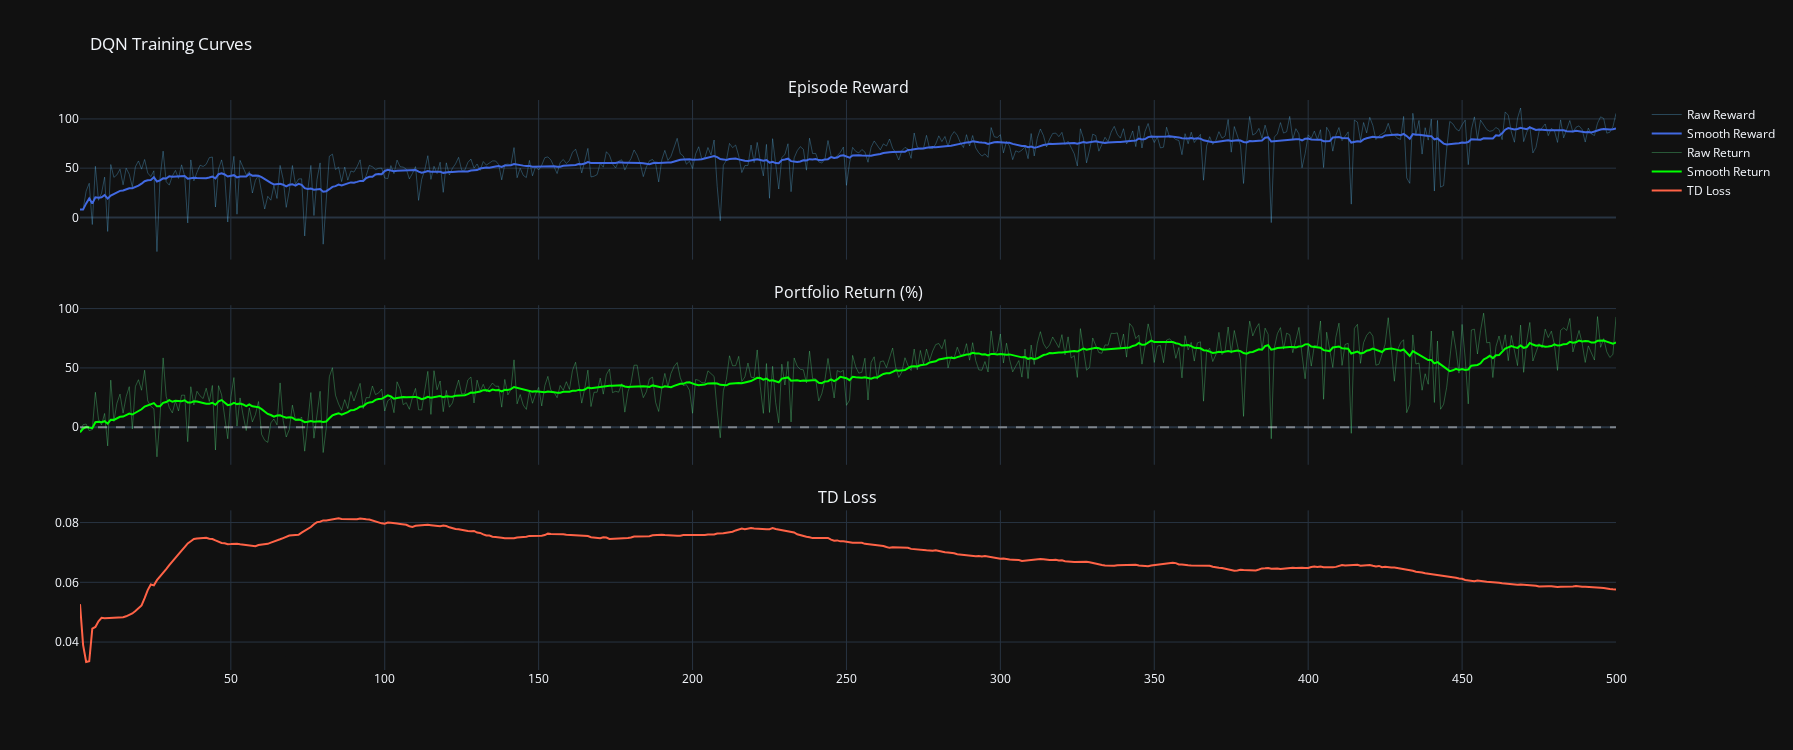

✅ Training curves saved.


In [8]:
fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=['Episode Reward', 'Portfolio Return (%)', 'TD Loss'],
                    vertical_spacing=0.08)

eps = list(range(1, len(episode_rewards) + 1))

# Smooth with rolling mean
smooth = lambda x, w=20: pd.Series(x).rolling(w, min_periods=1).mean().tolist()

fig.add_trace(go.Scatter(x=eps, y=episode_rewards, mode='lines',
                          line=dict(color='rgba(100,200,255,0.3)', width=1), name='Raw Reward'), row=1, col=1)
fig.add_trace(go.Scatter(x=eps, y=smooth(episode_rewards), mode='lines',
                          line=dict(color='royalblue', width=2), name='Smooth Reward'), row=1, col=1)

fig.add_trace(go.Scatter(x=eps, y=episode_returns, mode='lines',
                          line=dict(color='rgba(100,255,150,0.3)', width=1), name='Raw Return'), row=2, col=1)
fig.add_trace(go.Scatter(x=eps, y=smooth(episode_returns), mode='lines',
                          line=dict(color='lime', width=2), name='Smooth Return'), row=2, col=1)
fig.add_hline(y=0, line_dash='dash', line_color='white', opacity=0.4, row=2, col=1)

fig.add_trace(go.Scatter(x=eps, y=smooth(episode_losses), mode='lines',
                          line=dict(color='tomato', width=2), name='TD Loss'), row=3, col=1)

fig.update_layout(height=750, template='plotly_dark',
                  title='DQN Training Curves', showlegend=True)
fig.show()

RESULTS_DIR = BASE_DIR / 'results' / 'metrics'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
fig.write_html(str(RESULTS_DIR / 'dqn_training_curves.html'))
print('✅ Training curves saved.')

## 8. Load Best Agent & Final Eval

In [9]:
agent.load(MODEL_DIR / 'best_dqn.pth')
print(f'✅ Loaded best DQN | ε={agent.epsilon:.4f}')

# Full test on eval_env
state, _ = eval_env.reset()
port_history = [eval_env.initial_cap]
action_log   = []

for _ in range(eval_env.n_steps - 1):
    action = agent.online_net.act_greedy(state)
    state, _, done, _, info = eval_env.step(action)
    port_history.append(info['portfolio_value'])
    action_log.append(action)
    if done: break

final_value  = eval_env.portfolio_v
total_return = (final_value - eval_env.initial_cap) / eval_env.initial_cap * 100
n_trades     = len(eval_env.trade_log)

print('\n📊 Final Evaluation Results')
print('=' * 45)
print(f'  Initial Capital : ${eval_env.initial_cap:,.0f}')
print(f'  Final Value     : ${final_value:,.0f}')
print(f'  Total Return    : {total_return:+.2f}%')
print(f'  Number of Trades: {n_trades}')
print(f'  Action dist     : Hold={action_log.count(0)} Buy={action_log.count(1)} Sell={action_log.count(2)}')

# Save portfolio history for backtest notebook
with open(DATA_PROC / 'dqn_eval_portfolio.pkl', 'wb') as f:
    pickle.dump({
        'port_history': port_history,
        'action_log':   action_log,
        'trade_log':    eval_env.trade_log,
        'price_df':     eval_env.prices,
        'initial_cap':  eval_env.initial_cap,
    }, f)
print('\n✅ DQN eval data saved → data/processed/dqn_eval_portfolio.pkl')

✅ Loaded best DQN | ε=0.0100

📊 Final Evaluation Results
  Initial Capital : $100,000
  Final Value     : $111,621
  Total Return    : +11.62%
  Number of Trades: 32
  Action dist     : Hold=46 Buy=115 Sell=47

✅ DQN eval data saved → data/processed/dqn_eval_portfolio.pkl
